In [2]:
import utils_phenom as up
import utils_signal as usig
import importlib

importlib.reload(up)
import numpy as np
import matplotlib.pyplot as plt
from lal import MSUN_SI, PC_SI, C_SI, G_SI

/home/pycbc/work/All_memory/utils_phenom.py:4: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  from lal import MSUN_SI, PC_SI, C_SI, G_SI


         	Approximation will be used...
         	Approximation will be used...


         	Approximation will be used...


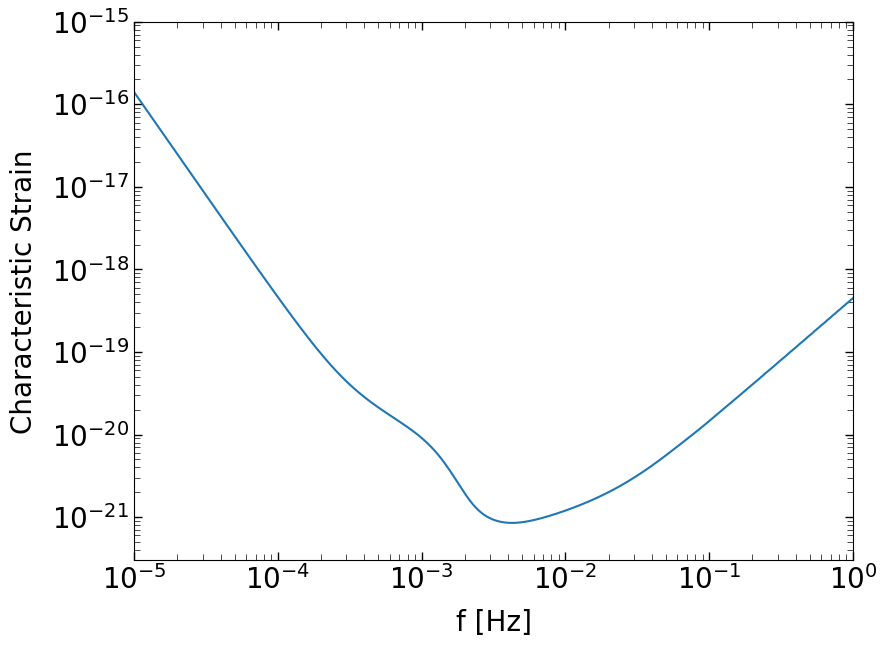

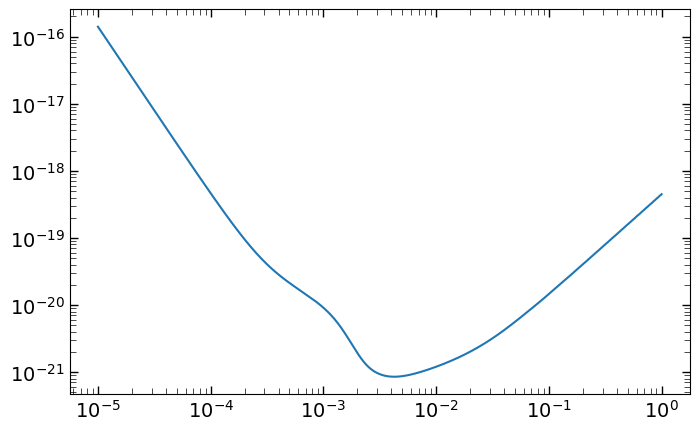

In [3]:
import LISA as li
lisa = li.LISA() # initialize LISA object

f  = np.logspace(np.log10(1.0e-5), np.log10(1.0e0), 1000)
Sn = lisa.Sn(f)
# Plot with the function from LISA module
li.PlotSensitivityCurve(f, Sn)
# Or we can do it ourselves - The same way as in the LISA.py
fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(f, np.sqrt(f*Sn))

In [4]:
et_sensitivities = {
    'ET-D': np.loadtxt('ET_D_sensi.txt'),
    'ET-B': np.loadtxt('ET_B_sensi.txt'),
    'ET-C': np.loadtxt('ET_C_sensi.txt')
}



det_styles = {
    'LISA':  {'color': 'black', 'ls': '-',   'lw': 2.0},
    'ET-D':  {'color': 'black', 'ls': '--',  'lw': 1.6},
    'ET-B':  {'color': 'black', 'ls': '-.',  'lw': 1.6},
    'ET-C':  {'color': 'black', 'ls': ':',   'lw': 1.6},
    'aLIGO': {'color': 'grey', 'ls': (0, (3, 1, 1, 1, 1, 1)), 'lw': 1.8},  # dash-dot-dot
}

# 1. 170817

In [ ]:
# Parameters 
t = np.linspace(-5., 50., 500000) 
r = 40  * 1e6  
theta = np.deg2rad(32)
# Dynamical ejecta
M_ej_dyn = 0.5*1e-2 
v_ej_dyn = 0.25 
tau_dyn_s = 1e-3  

start_dyn, end_dyn = -tau_dyn_s * np.log(3)*1e-3, 10*1e-3  

# Wind ejecta
M_ej_wind = 0.01 
v_ej_wind = 0.05 
tau_wind_s = 10  

start_wind, end_wind = 10*1e-3, 10 

# GRB
E_grb = 3e46
theta_j = np.deg2rad(5) # jet opening angle

phi_ej = 0
beta = 0.99
end_grb = 2


# Afterglow 
P_in = 1e50 # check !



Dyn - Wind - GRB - Afterglow

/home/pycbc/work/All_memory/utils_phenom.py:15: RuntimeWarning: overflow encountered in exp
  return (2*delta_h * (1/(1 + np.exp(-t / tau))-0.5))


Delta h for dynamical ejecta: 7.48e-25


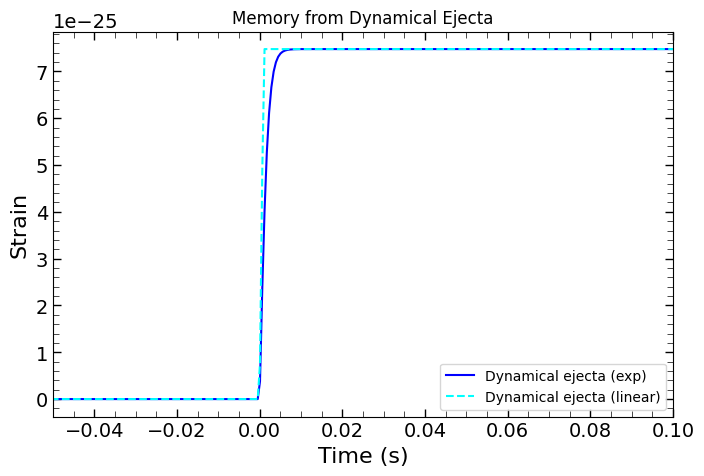

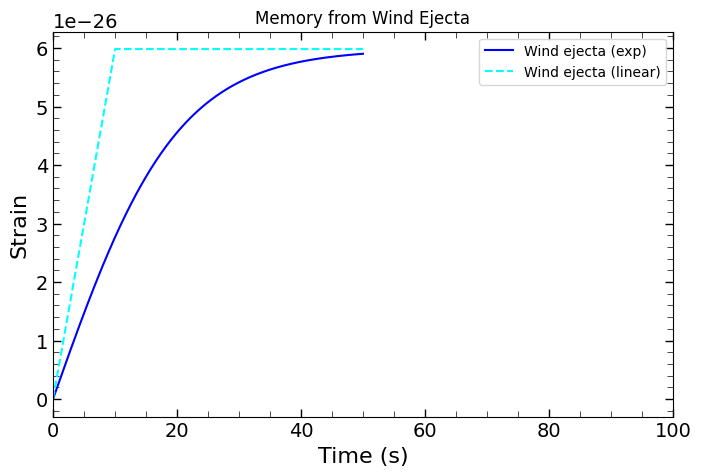

/home/pycbc/work/All_memory/utils_phenom.py:188: RuntimeWarning: overflow encountered in sinh
  h_f =  delta_h *np.pi * tau /( 1j*np.sinh( np.pi * f * tau))
/home/pycbc/work/All_memory/utils_phenom.py:188: RuntimeWarning: invalid value encountered in multiply
  h_f =  delta_h *np.pi * tau /( 1j*np.sinh( np.pi * f * tau))
/home/pycbc/work/All_memory/utils_phenom.py:188: RuntimeWarning: invalid value encountered in divide
  h_f =  delta_h *np.pi * tau /( 1j*np.sinh( np.pi * f * tau))


In [6]:
h_list = []
fft_list = []
t_list = []
f_list = []
# Dyn
h_t_dyn = up.linear_memory_ejecta_masked(t, M_ej_dyn, v_ej_dyn, tau_dyn_s, r, start_dyn, model='exponential')
h_t_dyn_lin = up.model_linear(t,up.delta_h_ejecta(M_ej_dyn, v_ej_dyn, r), tau_dyn_s, start_dyn)
H = up.delta_h_ejecta(M_ej_dyn, v_ej_dyn, r)
print(f"Delta h for dynamical ejecta: {H:.2e}")
plt.figure(figsize=(8,5))
plt.plot(t, h_t_dyn, label='Dynamical ejecta (exp)', color='blue')
plt.plot(t, h_t_dyn_lin, label='Dynamical ejecta (linear)', color='cyan', linestyle='--')
plt.xlabel('Time (s)')
plt.ylabel('Strain')
plt.xlim(-0.05, 0.1)
plt.title('Memory from Dynamical Ejecta')
plt.legend()
plt.show()

f, fft_dyn = up.fft_exp_model(h_t_dyn[-1], tau_dyn_s)
h_list.append(h_t_dyn)
fft_list.append(2*f*np.abs(fft_dyn))
t_list.append(t)
f_list.append(f)
# Wind
h_t_wind = up.linear_memory_ejecta_masked(t, M_ej_wind, v_ej_wind, tau_wind_s, r, start_wind, model='exponential')
h_t_wind_lin = up.model_linear(t,up.delta_h_ejecta(M_ej_wind, v_ej_wind, r), tau_wind_s, start_wind)

plt.figure(figsize=(8,5))
plt.plot(t, h_t_wind, label='Wind ejecta (exp)', color='blue')
plt.plot(t, h_t_wind_lin, label='Wind ejecta (linear)', color='cyan', linestyle='--')
plt.xlabel('Time (s)')
plt.ylabel('Strain')
plt.xlim(-0, 100)
plt.title('Memory from Wind Ejecta')
plt.legend()
plt.show()


f, fft_wind = up.fft_exp_model(h_t_wind[-1], tau_wind_s)
h_list.append(h_t_wind)
fft_list.append(2*f*np.abs(fft_wind))
t_list.append(t)
f_list.append(f)
# GRB
h_in = up.memory_initial_acceleration_GRB(E_grb, theta, phi_ej, r, beta)
# Afterglow
h_aft = up.memory_afterglow_injection(P_in, end_grb, theta, theta_j, r,  beta)
h_tot, _ = up.memory_total_waveform(t, h_in, h_aft, end_grb, theta)
f, fft_grb_aft = up.new_fft(h_in, h_aft, end_grb, theta)
h_list.append(h_tot)
fft_list.append(2*f*np.abs(fft_grb_aft))
t_list.append(t)
f_list.append(f)


labels = ['Dynamical ejecta', 'Wind ejecta', 'GRB + Afterglow']
colors = ['blue', 'red', 'green']

Nonlinear memory

         	Approximation will be used...


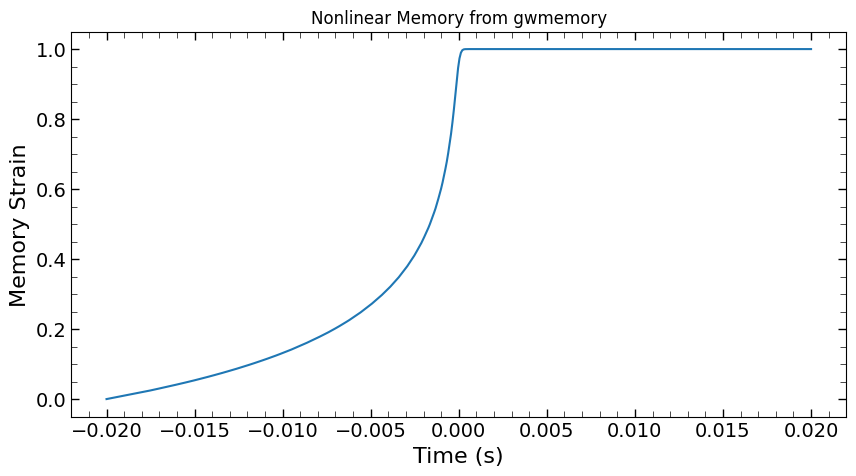

Characteristic timescale of the nonlinear memory signal: 4.01e-05 s


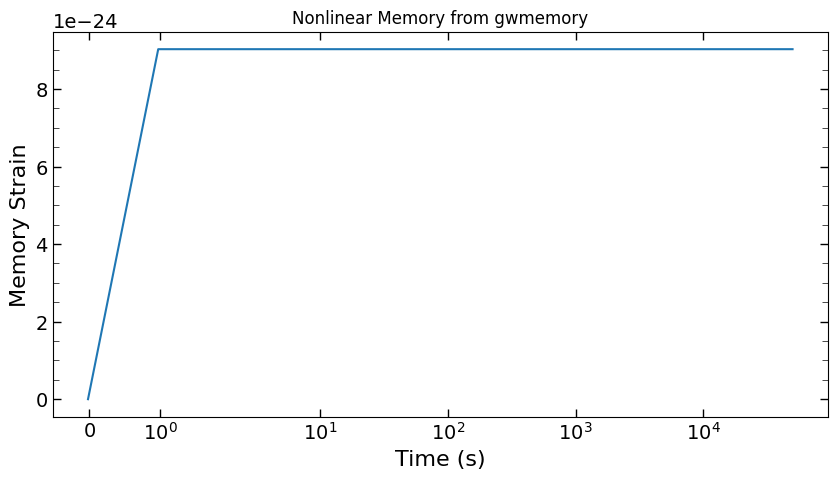

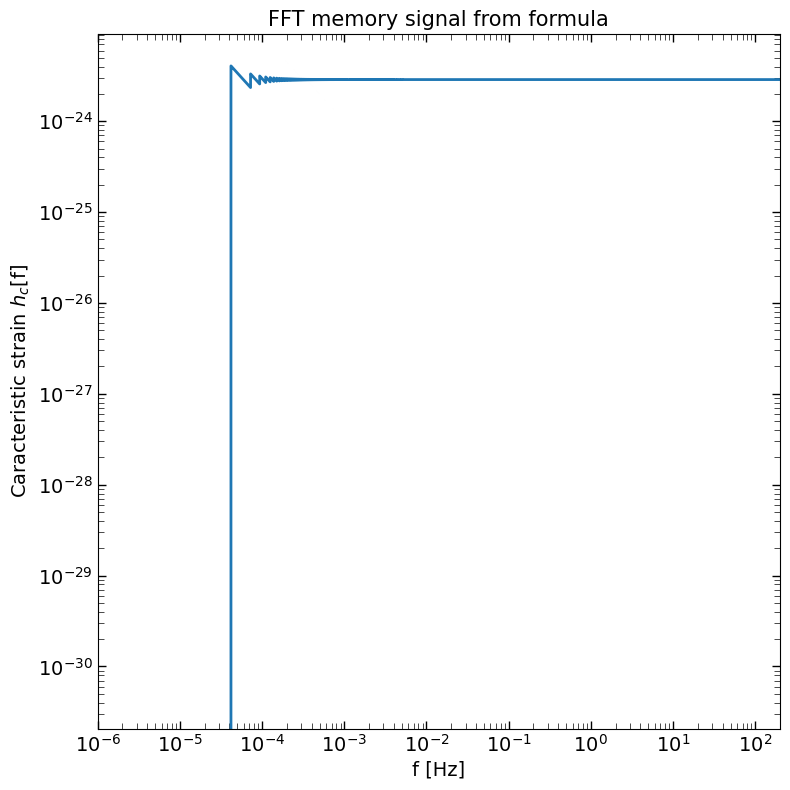

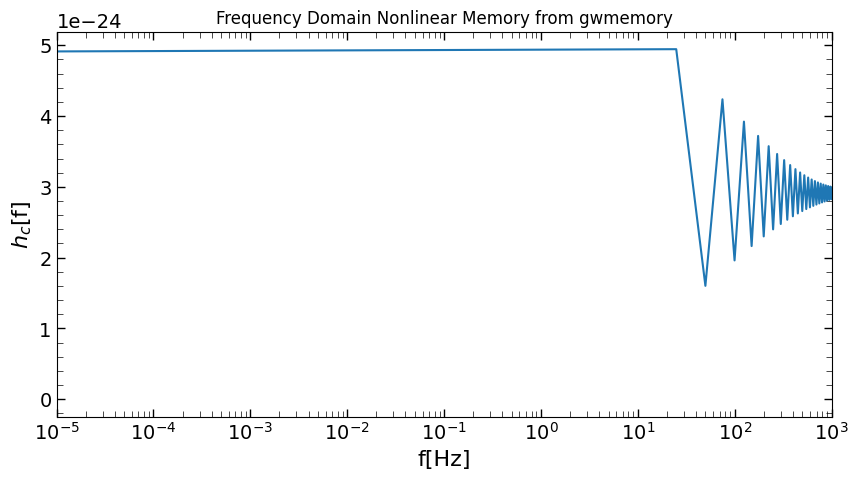

In [7]:
import utils_phenom as up
import utils_signal as using
import importlib
import gwmemory
importlib.reload(up)
import numpy as np
import matplotlib.pyplot as plt
# nonlinear memory with gwmemory
t_gwmemory = np.linspace(-0.02, 0.02, 500) # Less points either it crashes
m1 = 1.5
m2 = 1.2
q = m1/m2
parameters = dict(
        total_mass=2.74,
        distance=100,
        inc=np.pi/2,
        q=q,
        phase=0,
        spin_1=[0.0, 0.0, 0.0],
        spin_2=[0.0, 0.0, 0.0],
        times=t_gwmemory,
        model='IMRPhenomD'
        )
h_mem_gwmemory, t_mem_gwmemoy= gwmemory.time_domain_memory(**parameters)
h_mem_gwmemory = h_mem_gwmemory['plus']

# determine the characteristic timescale of the memory signal 
h = h_mem_gwmemory
t = t_gwmemory

# Normalize the signal
h_norm = (h - h[0]) / (h[-1] - h[0])
plt.figure(figsize=(10, 5))
plt.plot(t, h_norm)
plt.xlabel('Time (s)')
plt.ylabel('Memory Strain')
plt.title('Nonlinear Memory from gwmemory')
plt.show()
# Find the time where the signal reaches 95% of its final value
idx_90 = np.where(h_norm >= 0.95)[0][0]
t_char = t[idx_90]
print(f"Characteristic timescale of the nonlinear memory signal: {t_char:.2e} s")
# pad the signal up to 5e4 s
t_gwmemory_full = np.linspace(t_gwmemory[0], 5e4, int(5e4)+len(t_gwmemory))
h_mem_gwmemory_full = np.interp(t_gwmemory_full, t_gwmemory, h_mem_gwmemory)

h_list.append(h_mem_gwmemory_full)
t_list.append(t_gwmemory_full)
plt.figure(figsize=(10, 5))
plt.plot(t_gwmemory_full, h_mem_gwmemory_full)
plt.xscale('symlog', linscale=1.0)
plt.xlabel('Time (s)')
plt.ylabel('Memory Strain')
plt.title('Nonlinear Memory from gwmemory')
plt.show()

f, fft_nonlinear = up.memory_fft_formula(h_mem_gwmemory_full[-1], t_char, plot=True)

# Test with a freq_domain of gwmemory
h_mem, frequencies = gwmemory.frequency_domain_memory(**parameters)
fft_list.append( np.abs(h_mem['plus']))
f_list.append(frequencies)
plt.figure(figsize=(10, 5))
plt.plot(frequencies, 2 * frequencies * np.abs(h_mem['plus']))
plt.xscale('log')
plt.xlabel('f[Hz]')
plt.xlim(1e-5, 1e3)
plt.ylabel(r'$h_c$[f]')
plt.title('Frequency Domain Nonlinear Memory from gwmemory')
plt.show()



labels.append('Nonlinear Memory')
colors.append('purple')


Kilonova

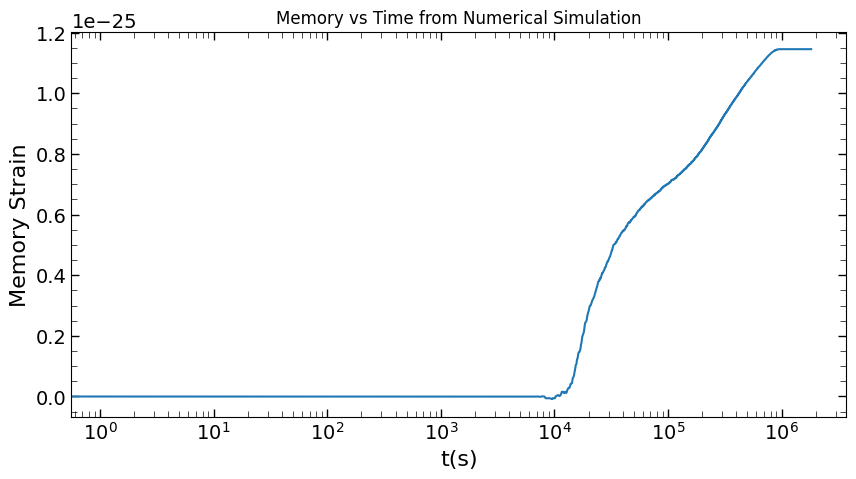

: 

In [ ]:
data = np.loadtxt('memory_vs_time_32deg.txt', skiprows=1)
time_data = data[:, 0]
memory_data = data[:, 1]

# Pad the signal from t=0 à t=time_data_seconds[0] par une valeur constante de 0
pad_times = np.linspace(0, time_data[0], len(time_data))  
pad_memory = np.zeros_like(pad_times)

# Concaténer le padding avec les données originales
time_data_seconds_padded = np.concatenate([pad_times, time_data])
memory_data_padded = np.concatenate([pad_memory, memory_data])

# Pad le signal sur 10 s après la fin du signal
pad_times_end = np.linspace(time_data_seconds_padded[-1], time_data_seconds_padded[-1] + 10, len(time_data))  
pad_memory_end = np.full_like(pad_times_end, memory_data_padded[-1])  # Pad avec la dernière valeur du signal
time_data_seconds_padded = np.concatenate([time_data_seconds_padded, pad_times_end])
memory_data_padded = np.concatenate([memory_data_padded, pad_memory_end])

plt.figure(figsize=(10, 5))
plt.plot(time_data_seconds_padded*24*3600, memory_data_padded)
plt.xlabel('t(s)')
plt.xscale('log')
plt.ylabel('Memory Strain')
plt.title('Memory vs Time from Numerical Simulation')
plt.show()

h_list.append(memory_data_padded)
t_list.append(time_data_seconds_padded* 24 * 3600)



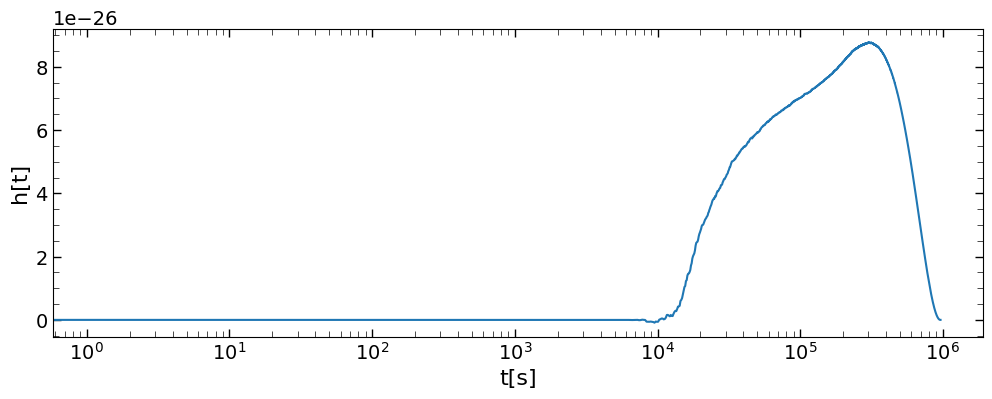

Sampling frequency: 8.75e-01 Hz


In [ ]:
data = np.loadtxt('memory_vs_time_32deg.txt', skiprows=1)
time_data = data[:, 0]
memory_data = data[:, 1]

# Pad the signal from t=0 à t=time_data_seconds[0] par une valeur constante de 0
pad_times = np.linspace(0, time_data[0], len(time_data))  
pad_memory = np.zeros_like(pad_times)

# Concaténer le padding avec les données originales
time_data_seconds_padded = np.concatenate([pad_times, time_data])
memory_data_padded = np.concatenate([pad_memory, memory_data])



import utils_signal as usig
memory_data_padded = usig.apply_window(memory_data_padded, window_type='tukey', alpha=0.8)

time_data_seconds_padded, memory_data_padded = usig.pad_signal(memory_data_padded, time_data_seconds_padded, r=0.3)
# convert days to seconds
time_data_seconds_padded = time_data_seconds_padded * 24 * 3600

plt.figure(figsize=(12,4))
plt.plot(time_data_seconds_padded, memory_data_padded)
plt.xscale('log')
plt.xlabel('t[s]')
plt.ylabel('h[t]')
plt.show()

import utils_simu as us

from scipy.signal import resample

def nfft(ht: np.ndarray, sampling_frequency: float, target_freq=1e4):
    """
    Performs an FFT while keeping track of the frequency bins,
    resampling if needed to reach target_freq in the output.

    Parameters
    ----------
    ht: array-like
        Time series to FFT
    sampling_frequency: float
        Sampling frequency of input time series
    target_freq: float
        Maximum frequency to reach in the output (Hz)

    Returns
    -------
    hf: array-like
        Single-sided FFT of ht normalised to units of strain / sqrt(Hz)
    ff: array-like
        Frequencies associated with hf
    """
    # Calculate required sampling frequency for target_freq
    required_fs = 2 * target_freq  # Nyquist

    if sampling_frequency < required_fs:
        # Upsample the signal
        duration = len(ht) / sampling_frequency
        new_length = int(duration * required_fs)
        ht = resample(ht, new_length)
        sampling_frequency = required_fs

    # Ensure even length
    if np.mod(len(ht), 2) == 1:
        ht = np.append(ht, 0)
    LL = len(ht)

    # Frequency range
    ff = sampling_frequency / 2 * np.linspace(0, 1, int(LL / 2 + 1))

    # FFT
    hf = np.fft.rfft(ht)
    hf = hf / sampling_frequency

    return hf, ff

sampling_frequency=1/(time_data_seconds_padded[1] - time_data_seconds_padded[0])
print(f"Sampling frequency: {sampling_frequency:.2e} Hz")


hf_kn, ff_kn = nfft(memory_data_padded, sampling_frequency=sampling_frequency)

#ff_kn, hf_kn =us.memory_fft(time_data_seconds_padded/(24*3600), memory_data_padded, window_type=None, plot_results=True)

plt.figure(figsize=(10, 5))
plt.plot(ff_kn,  2* ff_kn * np.abs(hf_kn))
plt.xscale('log')
plt.xlabel('f[Hz]')
plt.xlim(1e-6, 1e3)
plt.ylabel(r'$h_c$[f]')
plt.title('FFT of kilonova Memory from gwmemory')
plt.show()


fft_list.append(2*ff_kn*np.abs(hf_kn))

f_list.append(ff_kn)
labels.append('Kilonova Memory')
colors.append('orange')

Plot

0
1
2
3
4


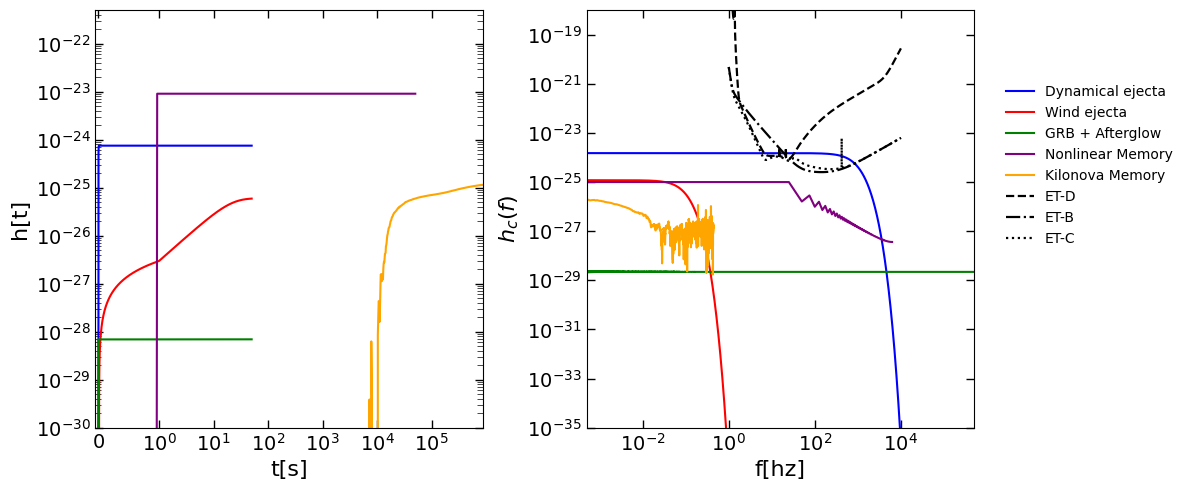

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12,5))
i = 0
for t, h, f, fft, label, color in zip(t_list, h_list, f_list, fft_list, labels, colors):
    print(i)
    ax[0].plot(t, h, label=label, color=color)
    ax[1].plot(f, fft, label=label, color=color)
    i+=1
ax[0].set_xlabel('t[s]')
ax[0].set_ylabel('h[t]')
ax[0].set_yscale('log')
ax[0].set_xscale('symlog', linthresh=1.0)
ax[0].set_xlim(-0.05, 24*3600*10)
ax[0].set_ylim(1e-30, 5e-22)



det_handles = []
# ET configurations
for det_label, data in et_sensitivities.items():
    s = det_styles[det_label]
    line, = ax[1].loglog(data[:, 0], data[:, 1],
                         color=s['color'], linestyle=s['ls'], linewidth=s['lw'],
                         label=det_label)
    det_handles.append(line)

ax[1].set_xscale('log')
ax[1].set_xlabel('f[hz]')
ax[1].set_ylabel(r'$h_c(f)$')
ax[1].set_xlim(5e-4, 5e5)
ax[1].set_ylim(1e-35, 1e-18)

ax[1].legend(loc = 'best', frameon=False, bbox_to_anchor=(1.05,0.85))
plt.tight_layout()
plt.show()



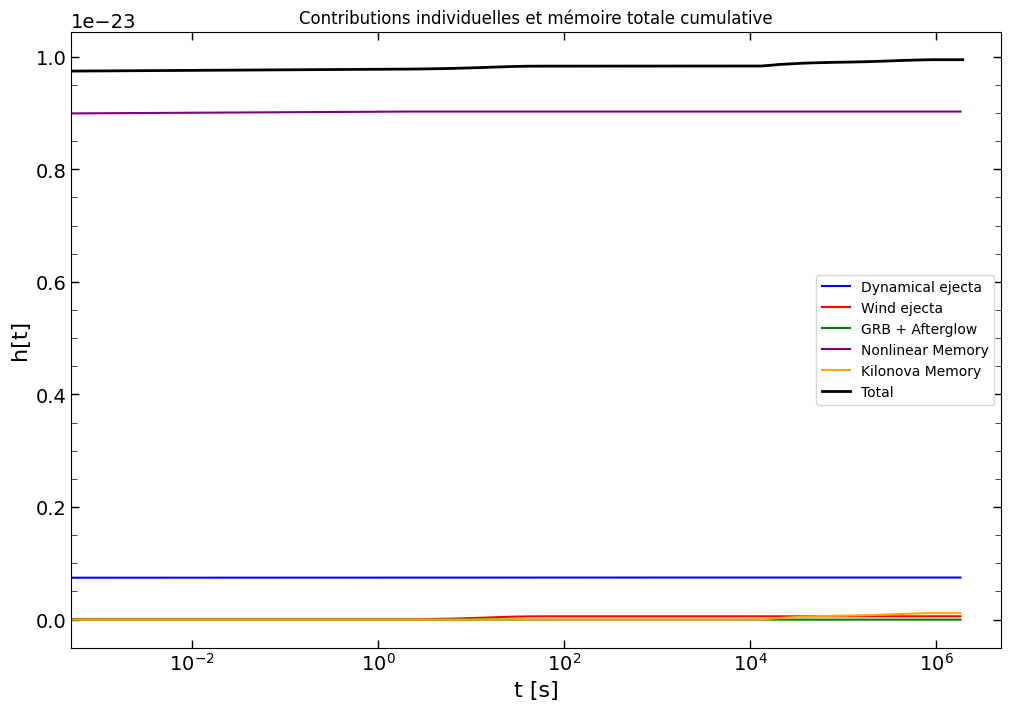

In [ ]:

from scipy.interpolate import interp1d

# Définir une grille temporelle commune
t_min = min([t[0] for t in t_list])
t_max = max([t[-1] for t in t_list])
N_points = max([len(t) for t in t_list]) * 5

t_common = np.linspace(t_min, t_max, N_points)

# Interpoler chaque mémoire sur la grille commune
h_interp_list = []
for t, h in zip(t_list, h_list):
    interp_func = interp1d(t, h, kind='linear', bounds_error=False, fill_value=(h[0], h[-1]))
    h_interp = interp_func(t_common)
    h_interp_list.append(h_interp)

# Somme cumulative
h_total = np.sum(h_interp_list, axis=0)

# Padding à droite sur 100 s avec la valeur finale
dt = t_common[1] - t_common[0]
N_pad = int(100000 / dt)
t_pad = np.linspace(t_common[-1] + dt, t_common[-1] + N_pad * dt, N_pad)
h_pad = np.full_like(t_pad, h_total[-1])

t_common_padded = np.concatenate([t_common, t_pad])
h_total_cum_padded = np.concatenate([h_total, h_pad])

# Plot contributions + somme
plt.figure(figsize=(12,8))
for h_interp, label, color in zip(h_interp_list, labels, colors):
    plt.plot(t_common, h_interp, label=label, color=color)
plt.plot(t_common_padded, h_total_cum_padded, label='Total', color='black', linewidth=2)
plt.xlabel('t [s]')
plt.ylabel('h[t]')
plt.title('Contributions individuelles et mémoire totale cumulative')
plt.xscale('log')

plt.xlim(5e-4, 5e6)
plt.legend()
plt.show()


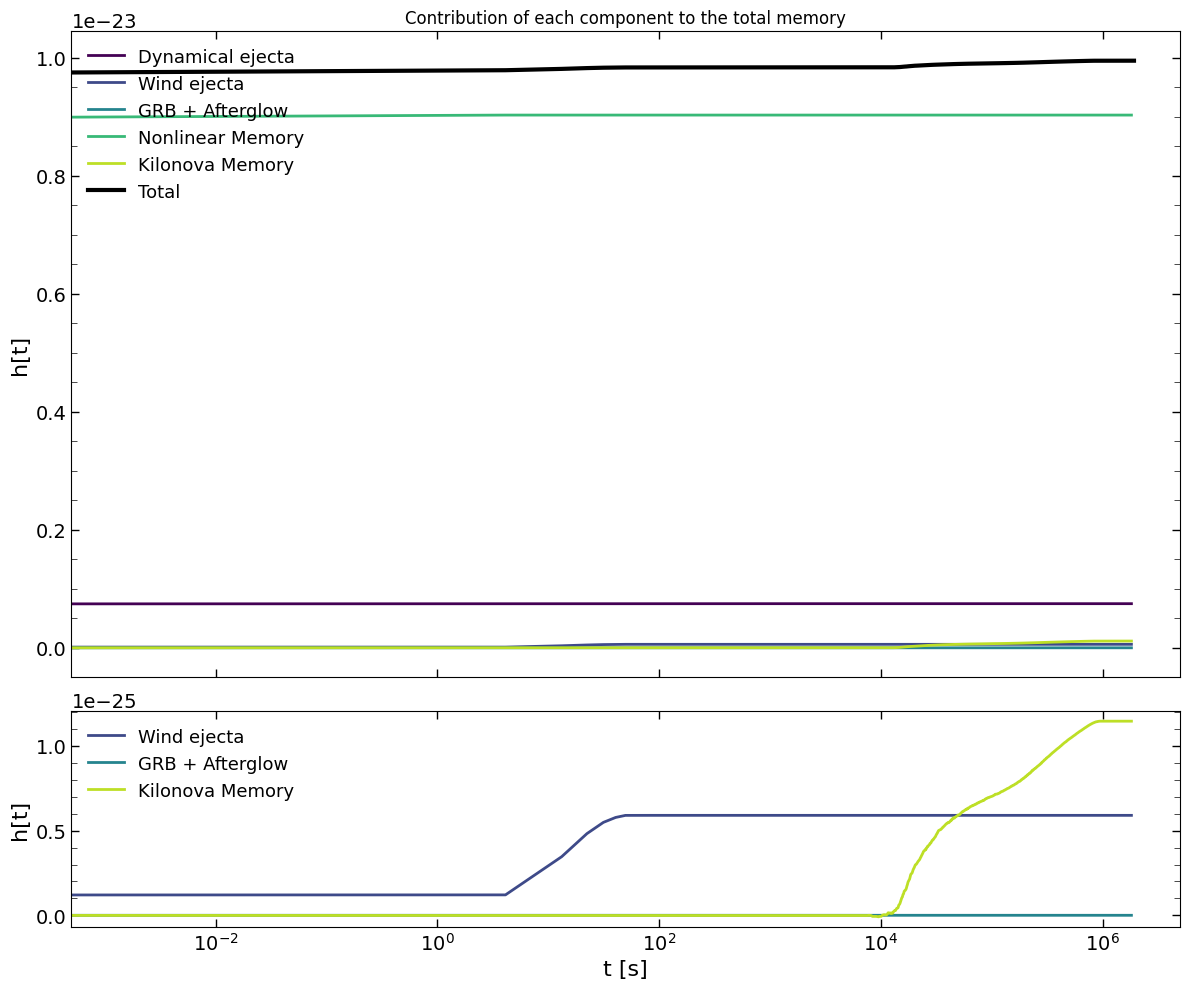

In [ ]:
from scipy.interpolate import interp1d
# colors = cmap viridis
cmap = plt.get_cmap('viridis')
colors = [cmap(i) for i in np.linspace(0, 0.9, len(labels))]
# Définir une grille temporelle commune
t_min = min([t[0] for t in t_list])
t_max = max([t[-1] for t in t_list])
N_points = max([len(t) for t in t_list]) * 2

t_common = np.linspace(t_min, t_max, N_points)

# Interpoler chaque mémoire sur la grille commune
h_interp_list = []
for t, h in zip(t_list, h_list):
    interp_func = interp1d(t, h, kind='linear', bounds_error=False, fill_value=(h[0], h[-1]))
    h_interp = interp_func(t_common)
    h_interp_list.append(h_interp)

# Somme simple
h_total = np.sum(h_interp_list, axis=0)

# Padding à droite sur 100 s avec la valeur finale
dt = t_common[1] - t_common[0]
N_pad = int(100000 / dt)
t_pad = np.linspace(t_common[-1] + dt, t_common[-1] + N_pad * dt, N_pad)
h_pad = np.full_like(t_pad, h_total[-1])

t_common_padded = np.concatenate([t_common, t_pad])
h_total_cum_padded = np.concatenate([h_total, h_pad])

# Plot principal + inset
fig, (ax_main, ax_inset) = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

# Plot principal : toutes les contributions + somme
for h_interp, label, color in zip(h_interp_list, labels, colors):
    ax_main.plot(t_common, h_interp, label=label, color=color, lw=2)
ax_main.plot(t_common_padded, h_total_cum_padded, label='Total', color='black', lw=3)
ax_main.set_ylabel('h[t]')
ax_main.set_title('Contribution of each component to the total memory')
ax_main.set_xscale('log')
ax_main.set_xlim(5e-4, 5e6)
ax_main.legend(loc = 'upper left', frameon=False, fontsize = 13)

# Inset : uniquement wind, grb+afterglow, kilonova
idx = [1, 2, 4]
for i in idx:
    ax_inset.plot(t_common, h_interp_list[i], label=labels[i], color=colors[i], lw=2)
ax_inset.set_xlabel('t [s]')
ax_inset.set_ylabel('h[t]')
ax_inset.set_xscale('log')
ax_inset.set_xlim(5e-4, 5e6)
ax_inset.legend(loc = 'upper left', frameon=False, fontsize = 13)


plt.tight_layout()
plt.show()

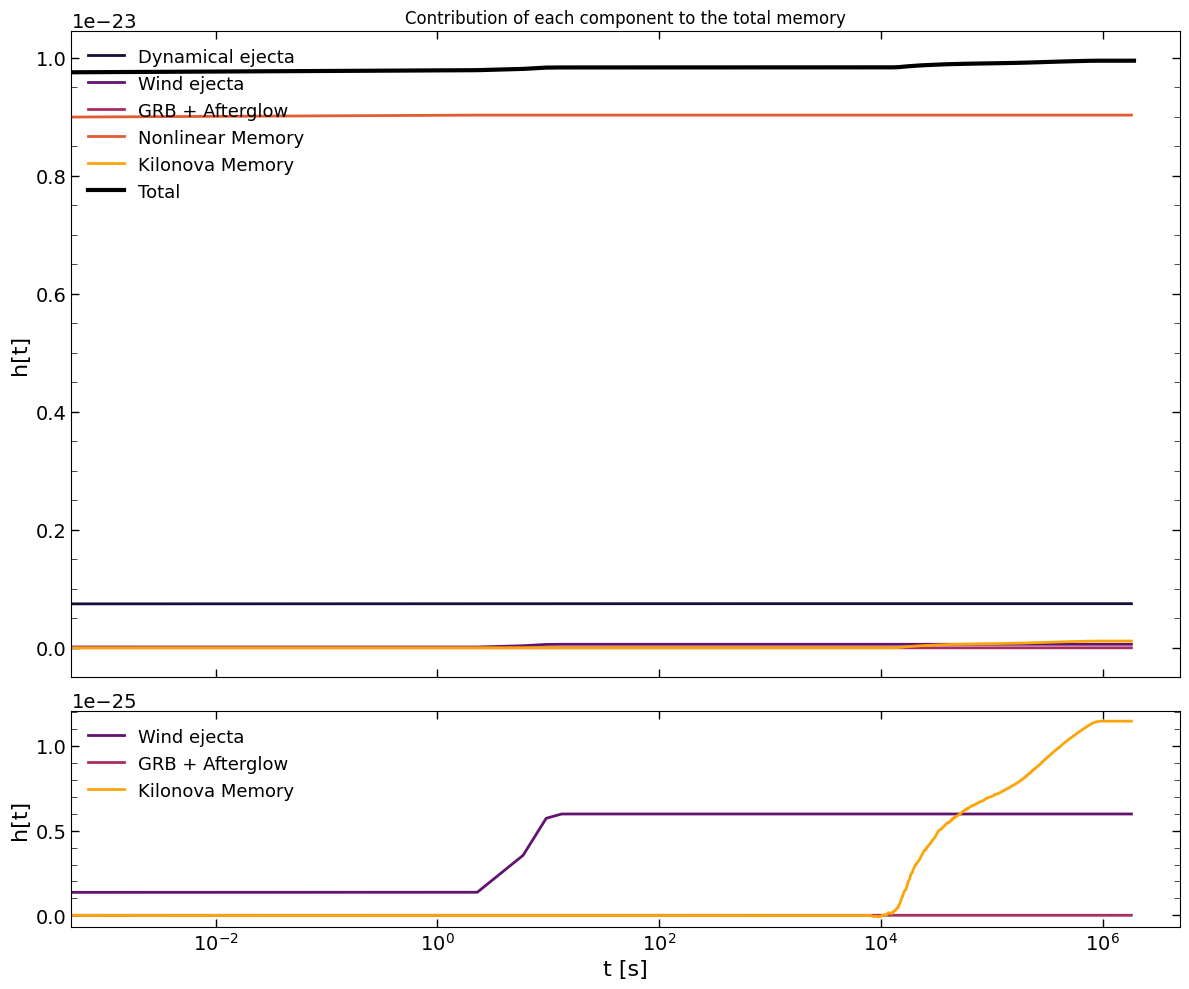

In [ ]:
# idem mais on remplace les modèles exp de dyn et wind par les modèles linéaires
h_list_lin = [h_t_dyn_lin, h_t_wind_lin, h_list[2], h_list[3], h_list[4]]
labels_lin = ['Dynamical ejecta (linear)', 'Wind ejecta (linear)', 'GRB + Afterglow', 'Nonlinear Memory', 'Kilonova Memory']
cmap = plt.get_cmap('inferno')
colors_lin = [cmap(i) for i in np.linspace(0.1, 0.8, len(labels_lin))]
# Définir une grille temporelle commune
t_min = min([t[0] for t in t_list])
t_max = max([t[-1] for t in t_list])
N_points = max([len(t) for t in t_list]) * 5

t_common = np.linspace(t_min, t_max, N_points)

# Interpoler chaque mémoire sur la grille commune
h_interp_list = []
for t, h in zip(t_list, h_list_lin):
    interp_func = interp1d(t, h, kind='linear', bounds_error=False, fill_value=(h[0], h[-1]))
    h_interp = interp_func(t_common)
    h_interp_list.append(h_interp)

# Somme simple
h_total = np.sum(h_interp_list, axis=0)

# Padding à droite sur 100 s avec la valeur finale
dt = t_common[1] - t_common[0]
N_pad = int(100000 / dt)
t_pad = np.linspace(t_common[-1] + dt, t_common[-1] + N_pad * dt, N_pad)
h_pad = np.full_like(t_pad, h_total[-1])

t_common_padded = np.concatenate([t_common, t_pad])
h_total_cum_padded = np.concatenate([h_total, h_pad])

# Plot principal + inset
fig, (ax_main, ax_inset) = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

# Plot principal : toutes les contributions + somme
for h_interp, label, color in zip(h_interp_list, labels, colors_lin):
    ax_main.plot(t_common, h_interp, label=label, color=color, lw=2)
ax_main.plot(t_common_padded, h_total_cum_padded, label='Total', color='black', lw=3)
ax_main.set_ylabel('h[t]')
ax_main.set_title('Contribution of each component to the total memory')
ax_main.set_xscale('log')
ax_main.set_xlim(5e-4, 5e6)
ax_main.legend(loc = 'upper left', frameon=False, fontsize = 13)

# Inset : uniquement wind, grb+afterglow, kilonova
idx = [1, 2, 4]
for i in idx:
    ax_inset.plot(t_common, h_interp_list[i], label=labels[i], color=colors_lin[i], lw=2)
ax_inset.set_xlabel('t [s]')
ax_inset.set_ylabel('h[t]')
ax_inset.set_xscale('log')
ax_inset.set_xlim(5e-4, 5e6)
ax_inset.legend(loc = 'upper left', frameon=False, fontsize = 13)


plt.tight_layout()
plt.show()